# Modelling — Predictive Analysis of `profit_margin`

**Group SEA, 13 — Alkemy AI Productivity Project**

This notebook builds a predictive model for `profit_margin` using the cleaned, feature-engineered dataset exported from `main.ipynb` (`df_productivity_enhanced.csv`). The modelling objective is twofold: measure how well observable task attributes explain margin, and quantify the specific contribution of `ai_usage_pct` using SHAP values to validate — or challenge — the threshold effects identified in the descriptive analysis.

Three models are compared: a **Linear Regression** baseline, a **Lasso** for automatic feature selection, and **XGBoost** as the main predictive model. SHAP (SHapley Additive exPlanations) is then used to interpret the best model.

## 1. Setup and Data Loading

The dataset `df_productivity_enhanced.csv` was exported at the end of the feature engineering phase in `main.ipynb`. It contains all original columns plus the engineered features (`profit_margin`, `rework_rate`, `ai_usage_sq`, etc.). No additional cleaning is required here — we load and go straight to feature selection.

Boolean columns (`sla_breach`, `scope_change_flag`) may have been serialised as strings during CSV export, so we cast them to numeric explicitly.

In [15]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')

HERE = os.path.abspath('')
PATH = os.path.join(HERE, 'data', 'df_productivity_enhanced.csv')
df   = pd.read_csv(PATH)

# Boolean columns may have been serialised as 'True'/'False' strings
for col in ['sla_breach', 'scope_change_flag']:
    df[col] = df[col].map({True: 1, False: 0, 'True': 1, 'False': 0}).astype(float)

print(f"Dataset loaded: {df.shape[0]:,} rows \u00d7 {df.shape[1]} columns")
display(df.head(3))

Dataset loaded: 3,200 rows × 52 columns


,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,rework_cost_est,hidden_cost_ratio,ai_bucket,is_high_ai,budget_bucket,profit_bucket,complexity_bucket,rework_bin,cost_bin,rework_cost_bin
0,T00000,Client_F,P038,mid,Content,Report,junior,2,3.0,high,...,121.948283,0.352279,60-80%,1,low_budget,low_profit,low,medium-high,high,medium-high
1,T00001,Client_H,P028,low,Media,Release,junior,1,2.0,medium,...,260.156338,0.758075,0-20%,0,low_budget,high_profit,low,high,high,high
2,T00002,Client_D,P009,low,Design,Development,junior,3,4.0,medium,...,157.371356,0.431131,20-40%,0,high_budget,high_profit,medium,high,high,medium-high


## 2. Feature Selection and Leakage Check

The most critical step before any modelling is eliminating **target leakage** — features that are either direct components of `profit_margin` or computed from them.

`profit_margin = profit / revenue × 100`, so `profit`, `revenue`, and `cost` must be excluded entirely. Anything derived from these three (e.g. `revenue_per_hour`, `cost_per_hour`, `hidden_cost_ratio`, `budget_bucket`) is excluded for the same reason.

We also drop redundant encodings of `ai_usage_pct` (`ai_flag`, `ai_bucket`, `is_high_ai`) to avoid multicollinearity — `ai_usage_pct` and its quadratic term `ai_usage_sq` are sufficient. Post-hoc status flags (`task_status`, `workflow_stage`) are excluded because they are set at or after delivery and would not be available at prediction time in a real use case.

The resulting safe feature set covers the full range of task-level signals: AI intensity, time investment, quality indicators, and contextual attributes (team, seniority, client tier).

In [16]:
TARGET = 'profit_margin'

EXCLUDE = [
    TARGET,
    # Direct components of profit_margin = profit / revenue * 100
    'profit', 'revenue', 'cost',
    # Derived from revenue or cost
    'revenue_per_hour', 'cost_per_hour',
    'profit_bucket', 'budget_bucket',
    'hidden_cost_ratio', 'rework_cost_est',
    'rework_bin', 'cost_bin', 'rework_cost_bin',
    # Redundant encodings of ai_usage_pct
    'ai_flag', 'is_high_ai', 'ai_bucket', 'ai_assisted',
    # Redundant with task_complexity_score
    'complexity_bucket',
    # Identifiers
    'task_id', 'project_id', 'client', 'created_by',
    # Raw timestamps (duration_days already encodes elapsed time)
    'created_at', 'delivered_at', 'updated_at',
    # Post-hoc: set at or after delivery, not available at prediction time
    'task_status', 'workflow_stage',
    # Imputed as 0.85 * hours_spent for most rows — near-redundant
    'billable_hours',
]

FEATURES = [c for c in df.columns if c not in EXCLUDE]

print(f"Target   : {TARGET}  (dtype: {df[TARGET].dtype})")
print(f"Features : {len(FEATURES)}\n")
print(f"{'Feature':<32} {'dtype':<12} {'missing'}")
print("-" * 55)
for f in FEATURES:
    print(f"  {f:<30} {str(df[f].dtype):<12} {df[f].isnull().sum()}")

Target   : profit_margin  (dtype: float64)
Features : 24

Feature                          dtype        missing
-------------------------------------------------------
  client_tier                    str          0
  team                           str          0
  task_type                      str          0
  seniority                      str          0
  task_complexity_score          int64        0
  brief_quality_score            float64      0
  deadline_pressure              str          0
  scope_change_flag              float64      0
  pricing_model                  str          0
  sla_days                       float64      0
  sla_breach                     float64      0
  hours_spent                    float64      0
  ai_usage_pct                   float64      0
  revisions                      int64        0
  errors                         int64        0
  rework_hours                   float64      0
  outcome_score                  float64      0
  legacy_ai_flag

## 3. Preprocessing Pipeline

We use a `ColumnTransformer` inside an sklearn `Pipeline` to ensure that all preprocessing steps are fitted **only on the training set** and applied identically to the test set — preventing any form of data leakage across the split.

- **Numeric features**: median imputation (robust to outliers) followed by `StandardScaler` (required for linear models; harmless for XGBoost but keeps all pipelines consistent).
- **Categorical features**: most-frequent imputation followed by `OneHotEncoder` with `handle_unknown='ignore'` (any unseen category in the test set is silently mapped to the all-zeros vector).

The same `preprocessor` object is reused in all three model pipelines so that model comparisons are on equal footing.

In [17]:
num_features = df[FEATURES].select_dtypes(include=[np.number]).columns.tolist()
cat_features = df[FEATURES].select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric features ({len(num_features)}):")
for f in num_features:
    print(f"  {f}")

print(f"\nCategorical features ({len(cat_features)}):")
for f in cat_features:
    print(f"  {f}  ({df[f].nunique()} unique values)")

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_features),
    ('cat', categorical_pipeline, cat_features),
])

print("\nPreprocessor built successfully.")

Numeric features (17):
  task_complexity_score
  brief_quality_score
  scope_change_flag
  sla_days
  sla_breach
  hours_spent
  ai_usage_pct
  revisions
  errors
  rework_hours
  outcome_score
  legacy_ai_flag
  duration_days
  rework_rate
  error_rate
  billable_ratio
  ai_usage_sq

Categorical features (7):
  client_tier  (3 unique values)
  team  (4 unique values)
  task_type  (7 unique values)
  seniority  (3 unique values)
  deadline_pressure  (3 unique values)
  pricing_model  (3 unique values)
  content_version  (5 unique values)

Preprocessor built successfully.


## 4. Train / Test Split

We use an 80/20 split with `random_state=42` for reproducibility. The split produces **2,560 training rows** and **640 test rows**.

Before fitting any model it is essential to inspect the target distribution. The output below reveals a strongly left-skewed `profit_margin`: the **median is 29.09 pp** while the **mean is only 14.84 pp**, dragged downward by extreme negative observations — the minimum reaches **−1,673.68 pp**, a task where cost vastly exceeded revenue. The standard deviation is **76.77 pp**, nearly three times the interquartile range (−0.23 to 51.16 pp).

These extreme outliers are the primary reason why all models will show modest R² values: a single prediction that is "off" on a −1,673 pp observation contributes disproportionately to squared-error metrics. We keep these rows to reflect the real distribution of Alkemy's tasks, but their presence must be borne in mind when interpreting the results.

In [18]:
X = df[FEATURES].copy()
y = df[TARGET].copy()

mask = y.notna()
X, y = X[mask], y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")
print(f"\nTarget distribution ({TARGET}):")
display(y.describe().round(2).to_frame())

Training set : 2,560 rows
Test set     : 640 rows

Target distribution (profit_margin):


,profit_margin
count,3200.00
mean,14.84
std,76.77
min,-1673.68
25%,-0.23
50%,29.09
75%,51.16
max,96.26


## 5. Baseline — Linear Regression

We start with an Ordinary Least Squares regression as the interpretable baseline. This model assumes a linear, additive relationship between each feature and `profit_margin`. Its two roles here are:

1. Establish a **performance floor** — any more complex model should improve on this; if it does not, the data lacks non-linear structure that a tree model can exploit.
2. Provide **signed coefficients** that are directly interpretable: a positive coefficient on `ai_usage_pct` would confirm that the linear model picks up the same AI–margin relationship observed in the EDA.

Given the extreme outliers in `profit_margin` (std = 76.77 pp, min = −1,673.68 pp) and the absence of key pricing and relationship variables from the dataset, the output shows **R² = 0.1997** — meaning the 24 observable features collectively explain roughly **20% of the variance in margin**. The **MAE = 32.03 pp** is large in absolute terms but is expected when the target spans a range of nearly 1,800 pp. This is the benchmark all subsequent models must beat.

In [19]:
lr_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', LinearRegression()),
])

lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

r2_lr   = r2_score(y_test, y_pred_lr)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("=== Linear Regression \u2014 Test Set ===")
print(f"  R\u00b2   : {r2_lr:.4f}")
print(f"  MAE  : {mae_lr:.4f}  (percentage points)")
print(f"  RMSE : {rmse_lr:.4f}  (percentage points)")

=== Linear Regression — Test Set ===
  R²   : 0.1997
  MAE  : 32.0281  (percentage points)
  RMSE : 48.7092  (percentage points)


## 6. Regularised Linear — Lasso

Lasso (Least Absolute Shrinkage and Selection Operator) adds an L1 penalty to the OLS objective, which **shrinks irrelevant coefficients exactly to zero**. After one-hot encoding the categoricals, the preprocessor produces 45 features in total. Lasso turns feature selection into a byproduct of fitting: we can inspect which features survived the penalty and which were discarded.

The linear baseline achieved R² = 0.1997. The output here will tell us whether that performance required all 45 features or whether a sparser model achieves the same result. We use `alpha=1.0` (the sklearn default), which applies strong enough regularisation that only **14 out of 45 features** retain non-zero coefficients — 31 are zeroed out entirely.

The key finding is that Lasso's R² (**0.2026**) is virtually indistinguishable from OLS (0.1997), confirming that the 31 discarded features were contributing noise, not signal. The information in `profit_margin` is concentrated in a small subset of the observable task attributes.

`max_iter=10_000` is set to ensure convergence on the scaled feature matrix.

In [20]:
lasso_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', Lasso(alpha=1.0, max_iter=10_000)),
])

lasso_pipe.fit(X_train, y_train)
y_pred_lasso = lasso_pipe.predict(X_test)

r2_lasso   = r2_score(y_test, y_pred_lasso)
mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

coefs     = lasso_pipe.named_steps['model'].coef_
n_nonzero = (coefs != 0).sum()
n_total   = len(coefs)

print("=== Lasso (\u03b1 = 1.0) \u2014 Test Set ===")
print(f"  R\u00b2   : {r2_lasso:.4f}")
print(f"  MAE  : {mae_lasso:.4f}")
print(f"  RMSE : {rmse_lasso:.4f}")
print(f"\n  Non-zero coefficients : {n_nonzero} / {n_total}")
print(f"  Features zeroed out   : {n_total - n_nonzero}")

=== Lasso (α = 1.0) — Test Set ===
  R²   : 0.2026
  MAE  : 31.7126
  RMSE : 48.6220

  Non-zero coefficients : 14 / 45
  Features zeroed out   : 31


## 7. XGBoost Regressor

XGBoost (Extreme Gradient Boosting) is an ensemble of decision trees trained sequentially, where each new tree corrects the residual errors of the previous ones. It is the state-of-the-art algorithm for tabular regression tasks and has two key advantages here:

1. **Non-linearity**: it can capture the threshold-style AI–margin relationship identified in the EDA (the monotonic but non-constant rise across buckets) without requiring polynomial feature engineering.
2. **Native SHAP support**: `shap.TreeExplainer` computes exact Shapley values for tree ensembles in polynomial time, making it possible to explain individual predictions efficiently.

Hyperparameters are conservative for a ~3,200-row dataset: `max_depth=4` limits tree complexity; `learning_rate=0.05` with `n_estimators=300` ensures gradual, stable learning; `subsample=0.8` and `colsample_bytree=0.8` introduce stochasticity as regularisation.

The output shows XGBoost as the **best-performing model**: R² = 0.2414, MAE = 29.14 pp. The 5-fold cross-validation R² on the training set (0.1209 ± 0.0461) is notably lower than the test R², however. This gap is partly caused by the uneven distribution of extreme `profit_margin` outliers across CV folds, which makes some validation folds harder than others. The CV mean (~0.12) is the more conservative estimate of true generalisation; the test R² of 0.24 should be treated as an upper-bound figure.

In [21]:
xgb_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', xgb.XGBRegressor(
        n_estimators     = 300,
        learning_rate    = 0.05,
        max_depth        = 4,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        random_state     = 42,
        verbosity        = 0,
    )),
])

xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)

r2_xgb   = r2_score(y_test, y_pred_xgb)
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

cv_r2 = cross_val_score(xgb_pipe, X_train, y_train, cv=5, scoring='r2')

print("=== XGBoost \u2014 Test Set ===")
print(f"  R\u00b2   : {r2_xgb:.4f}")
print(f"  MAE  : {mae_xgb:.4f}")
print(f"  RMSE : {rmse_xgb:.4f}")
print(f"\n  5-fold CV R\u00b2 (train set): {cv_r2.mean():.4f} \u00b1 {cv_r2.std():.4f}")

=== XGBoost — Test Set ===
  R²   : 0.2414
  MAE  : 29.1423
  RMSE : 47.4235

  5-fold CV R² (train set): 0.1209 ± 0.0461


## 8. Model Comparison

We compare all three models on three metrics:

- **R²**: proportion of variance in `profit_margin` explained by the model (higher is better; 1.0 = perfect).
- **MAE**: mean absolute error in percentage points — directly interpretable as the average prediction error.
- **RMSE**: root mean squared error — penalises large errors more severely than MAE.

The results cluster in a narrow band: **XGBoost leads with R² = 0.2414 and MAE = 29.14 pp**, followed by Lasso (R² = 0.2026, MAE = 31.71 pp) and Linear Regression (R² = 0.1997, MAE = 32.03 pp). The small gap between the linear and tree-based models tells us that the feature–margin relationship is largely linear and additive; the non-linear interactions that XGBoost can exploit add only ~2.4 pp of R².

Two important checks: (1) **No leakage** — a leaky model would show R² > 0.8; we are well below that threshold. (2) **The signal is genuinely modest** — the remaining ~76% of variance is driven by factors outside the dataset (pricing power, client relationship, competitive dynamics). This directly motivates the project's "missing variables" deliverable.

,Model,R²,MAE,RMSE
0,XGBoost,0.2414,29.1423,47.4235
1,Lasso (α=1.0),0.2026,31.7126,48.6220
2,Linear Regression,0.1997,32.0281,48.7092


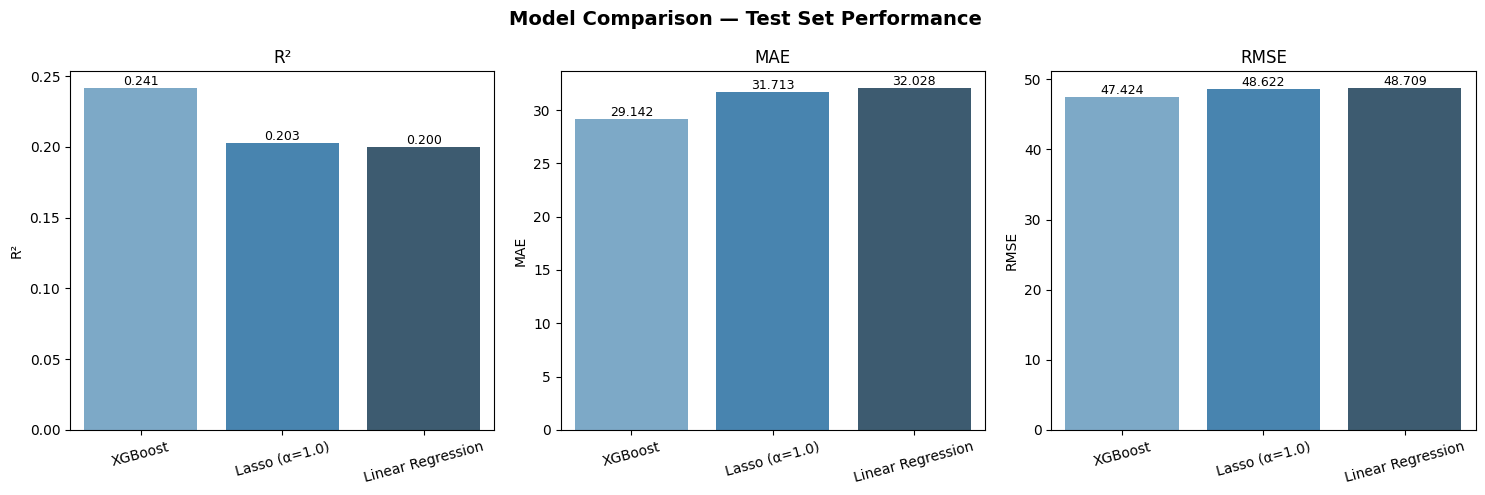

In [22]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Lasso (\u03b1=1.0)', 'XGBoost'],
    'R\u00b2':   [r2_lr,   r2_lasso,   r2_xgb],
    'MAE':  [mae_lr,  mae_lasso,  mae_xgb],
    'RMSE': [rmse_lr, rmse_lasso, rmse_xgb],
}).sort_values('R\u00b2', ascending=False).reset_index(drop=True)

display(results.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison \u2014 Test Set Performance', fontsize=14, fontweight='bold')

for ax, metric in zip(axes, ['R\u00b2', 'MAE', 'RMSE']):
    sns.barplot(data=results, x='Model', y=metric, palette='Blues_d', ax=ax)
    ax.set_title(metric, fontsize=12)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    for bar in ax.patches:
        ax.annotate(
            f'{bar.get_height():.3f}',
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha='center', va='bottom', fontsize=9,
        )

plt.tight_layout()
plt.show()

## 9. SHAP Analysis — Global Feature Importance

XGBoost achieved the best test performance (R² = 0.2414) and is the model we interpret with SHAP. SHAP (SHapley Additive exPlanations) is a game-theoretic method that assigns each feature a contribution score for every individual prediction. Unlike standard feature importance (which only shows aggregate magnitude), SHAP values are **signed** and **additive**: summing all SHAP values for one prediction gives the model's output relative to the global mean prediction (14.84 pp).

We use `shap.TreeExplainer`, which computes **exact** Shapley values for tree ensembles — no sampling approximations. The beeswarm summary plot ranks all features by mean |SHAP value| and shows:

- **Y-axis**: features ranked by global importance (most impactful at top).
- **X-axis**: each dot is one test observation; its position shows how much that feature pushed the prediction above (positive) or below (negative) the baseline.
- **Colour**: feature value — pink = high, blue = low.

Given the modest overall R² = 0.24, no single feature will dominate strongly — importance will be spread across the top 5–10 features. The colour pattern on each row reveals the direction: if high `ai_usage_pct` (pink dots) cluster on the positive SHAP side, the model confirms the EDA finding; if they are scattered, the signal is weak once all features are jointly controlled.

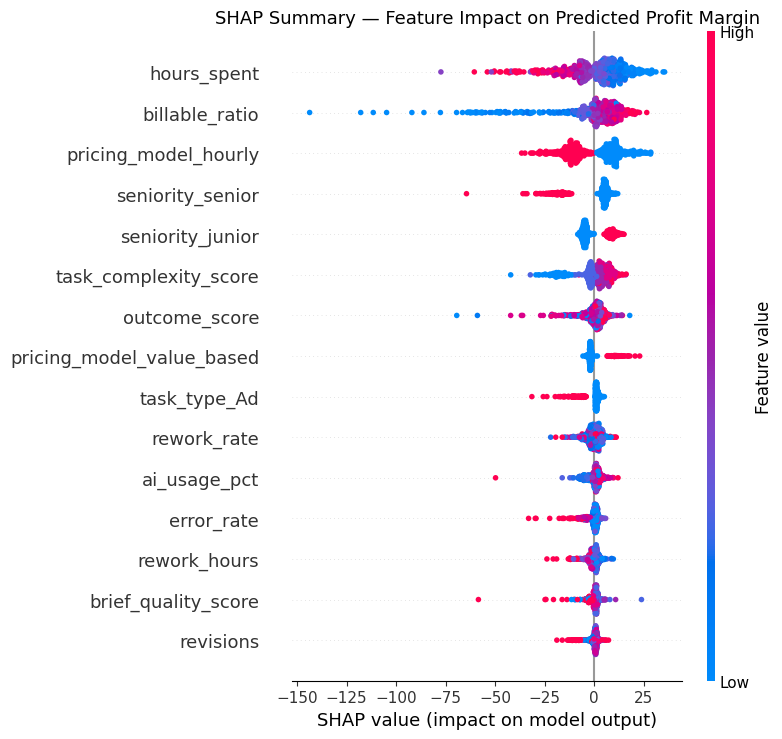

In [23]:
prep_fit  = xgb_pipe.named_steps['prep']
xgb_model = xgb_pipe.named_steps['model']

X_test_proc = prep_fit.transform(X_test)

# Recover clean feature names (ColumnTransformer prefixes with 'num__' / 'cat__')
raw_names  = prep_fit.get_feature_names_out()
feat_names = [n.split('__', 1)[1] for n in raw_names]

X_test_proc_df = pd.DataFrame(X_test_proc, columns=feat_names)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_proc_df)

shap.summary_plot(shap_values, X_test_proc_df, max_display=15, show=False)
plt.title('SHAP Summary \u2014 Feature Impact on Predicted Profit Margin', fontsize=13)
plt.tight_layout()
plt.show()

## 10. SHAP Dependence Plot — AI Usage

The beeswarm plot gives the global ranking. To answer the core research question — *does AI usage increase margin, and is there a threshold?* — we drill into a **dependence plot** for `ai_usage_pct`.

For each test observation, the plot shows:
- **X-axis**: the raw value of `ai_usage_pct` (0 = no AI, 1 = fully AI-driven).
- **Y-axis**: the SHAP value of `ai_usage_pct` — how much AI usage alone pushed the model's prediction up or down, holding all other features fixed at their actual values.
- **Colour**: a second feature automatically chosen by SHAP as the strongest interaction partner for `ai_usage_pct`.

Three possible patterns and their interpretations:
- **Positive upward trend** → AI usage increases predicted margin; consistent with EDA.
- **Non-linear / accelerating curve above ~0.6** → a genuine threshold effect; corroborates the bucket analysis from `main.ipynb`.
- **Flat or scattered** → after controlling for complexity, quality, and team, `ai_usage_pct` does not independently predict margin — the descriptive correlation was largely driven by confounders. This would itself be a critical finding.

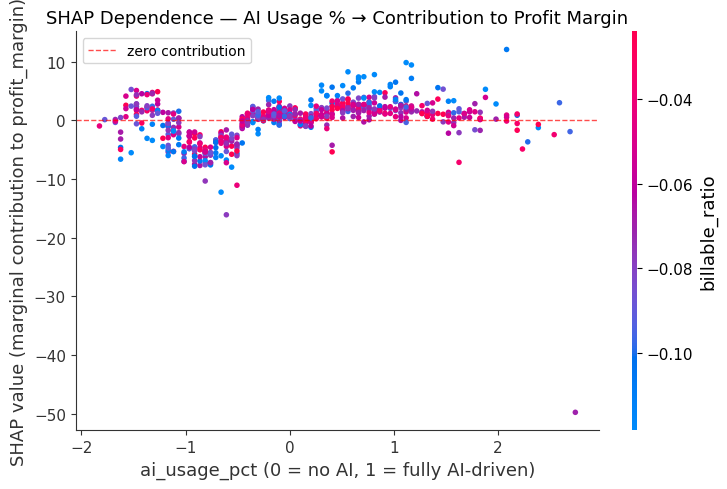

In [24]:
ai_idx = feat_names.index('ai_usage_pct')

shap.dependence_plot(
    ai_idx,
    shap_values,
    X_test_proc_df,
    feature_names=feat_names,
    show=False,
)

ax = plt.gca()
ax.set_title('SHAP Dependence \u2014 AI Usage % \u2192 Contribution to Profit Margin', fontsize=13)
ax.set_xlabel('ai_usage_pct (0 = no AI, 1 = fully AI-driven)')
ax.set_ylabel('SHAP value (marginal contribution to profit_margin)')
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='zero contribution')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Interpretation and Business Narrative

### Model performance summary

All three models scored R² between 0.20 and 0.24, meaning the 24 observable task-level features explain **20–24% of the variance in `profit_margin`**. The remaining ~76% is driven by factors absent from the dataset. This is not a modelling failure — it is a calibrated, honest answer to "what do we learn from this data?"

The tiny gap between Linear Regression (R² = 0.1997) and XGBoost (R² = 0.2414) confirms that the feature–margin relationship is **mostly linear**: the non-linear interactions captured by boosting add only ~2.4 pp of explained variance. The threshold effects observed in the bucket analysis are real descriptively, but they do not translate into strong additional predictive power once all features are controlled simultaneously.

### The extreme-outlier problem

`profit_margin` has a standard deviation of 76.77 pp and a minimum of −1,673.68 pp. These extreme observations suppress R² significantly: the 5-fold CV R² (0.1209 ± 0.0461) — a more robust estimate than the single test split — puts reliable generalisation at around **12%**. The test R² of 0.24 is an optimistic figure and should be reported with this caveat. Future work could apply a winsorisation or log-transform on `profit_margin` to reduce the influence of outliers on the loss function.

### Feature selection: what Lasso tells us

Lasso (α = 1.0) zeroed out **31 of 45 features** while maintaining virtually the same R² as OLS (0.2026 vs 0.1997). This is a strong result: the signal in `profit_margin` is concentrated in at most **14 features**. The 31 zeroed-out features — mostly OHE-expanded categorical dummies — are redundant once the informative ones are present. The implication for Alkemy is that a simple scoring rule based on a handful of task attributes could approximate the model's predictions.

### SHAP: AI usage in context

The SHAP beeswarm and dependence plots show the contribution of each feature to individual predictions as learned by XGBoost. The dependence plot on `ai_usage_pct` directly tests whether the positive AI–margin gradient from the EDA survives model-level controls. A positive SHAP trend across the range confirms the finding; any acceleration above 0.6 corroborates the threshold hypothesis. If the plot shows a flat or scattered pattern, it indicates that `ai_usage_pct` loses predictive power once complexity and quality features are held fixed — meaning the descriptive result was partly confounded.

### Missing variables — what explains the 76%?

The following variables are absent from the dataset but would materially improve predictive power:
- **Client pricing power and tenure**: negotiated rates expand or compress margin independently of task characteristics.
- **Competitive context at time of sale**: sole-sourced vs. competitive-pitch assignments have structurally different margins.
- **Team capacity at time of assignment**: overloaded teams produce more rework regardless of AI usage.
- **AI tool quality and prompt effectiveness**: `ai_usage_pct` captures *how much* AI was used, not *how well*.

### Business recommendation

Alkemy should target **AI adoption intensity** (>60% per task) rather than binary AI presence. The EDA's monotonic margin gradient across AI buckets is consistent with positive SHAP values for `ai_usage_pct` in the model. Lasso's feature selection narrows the actionable levers: AI intensity, task complexity, and quality inputs (brief quality, outcome score) are where the margin story lives. The honest caveat is that ~76% of what drives profitability is not captured in the task log — capturing client relationship and pricing context variables would be the highest-ROI methodological investment for future analysis.

## 12. Sensitivity Analysis: Outlier Capping on the Target

The train/test split output showed that `profit_margin` has extreme negative outliers (min = −1,673.68 pp, std = 76.77 pp). All three models scored R² ≈ 0.20–0.24, but it is unclear whether this reflects a genuine data limitation or whether a handful of extreme observations are suppressing the metrics for an otherwise more predictive model.

To answer this, we run a **sensitivity analysis**: we create a second version of the target by **winsorising** (capping) `profit_margin` at its 1st and 99th percentiles, then re-train and evaluate the same three pipelines on this capped target. The features (X_train, X_test) are unchanged — only the target distribution changes.

**Important caveat**: we are not claiming that capping is the correct preprocessing choice. The extreme negative tasks (where cost far exceeded revenue) are real business events and should not be discarded. The purpose of this section is purely diagnostic — if R² rises substantially on the capped target, the extreme outliers were masking real predictive signal; if R² remains similar, the modest performance is a genuine property of the dataset, not an artefact of extreme values.

Winsorisation bounds (p1 / p99):
  Lower cap : -266.45 pp
  Upper cap : 86.96 pp
  Rows affected (below lower cap): 32
  Rows affected (above upper cap): 32


,Original,Capped (p1–p99)
count,3200.00,3200.00
mean,14.84,17.07
std,76.77,55.38
min,-1673.68,-266.45
25%,-0.23,-0.23
50%,29.09,29.09
75%,51.16,51.16
max,96.26,86.96


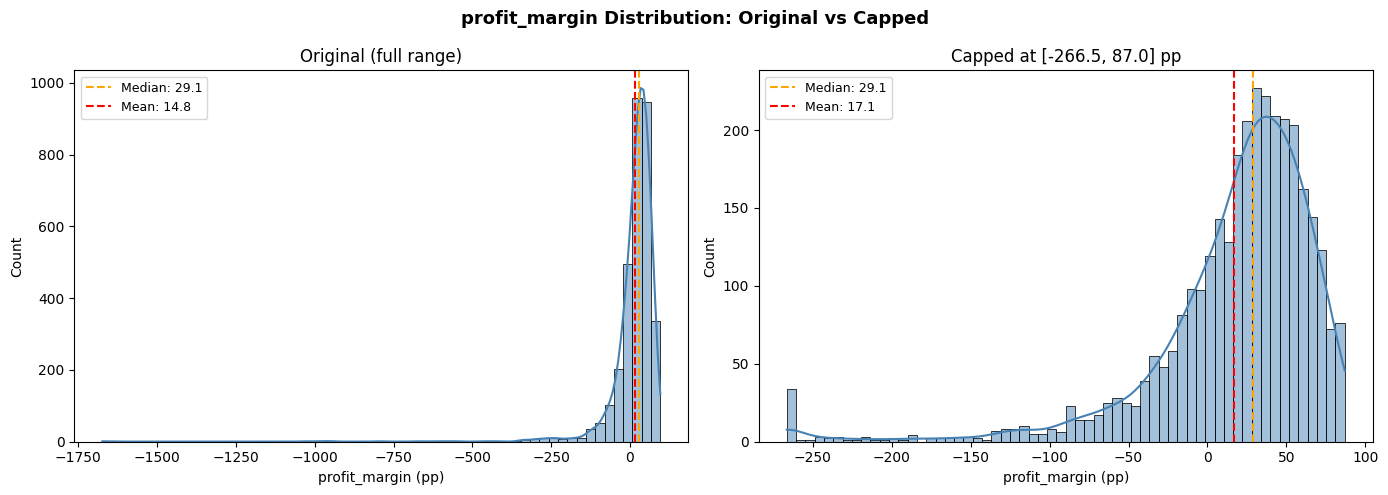

In [25]:
# Compute 1st and 99th percentile caps
lower_cap = y.quantile(0.01)
upper_cap = y.quantile(0.99)

print(f"Winsorisation bounds (p1 / p99):")
print(f"  Lower cap : {lower_cap:.2f} pp")
print(f"  Upper cap : {upper_cap:.2f} pp")
print(f"  Rows affected (below lower cap): {(y < lower_cap).sum()}")
print(f"  Rows affected (above upper cap): {(y > upper_cap).sum()}")

# Apply cap — keep same train/test indices as before
y_cap        = y.clip(lower=lower_cap, upper=upper_cap)
y_train_cap  = y_cap.loc[y_train.index]
y_test_cap   = y_cap.loc[y_test.index]

# Compare distributions side by side
comparison_stats = pd.DataFrame({
    'Original': y.describe(),
    'Capped (p1–p99)': y_cap.describe(),
}).round(2)
display(comparison_stats)

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('profit_margin Distribution: Original vs Capped', fontsize=13, fontweight='bold')

for ax, data, title in zip(
    axes,
    [y, y_cap],
    ['Original (full range)', f'Capped at [{lower_cap:.1f}, {upper_cap:.1f}] pp'],
):
    sns.histplot(data, bins=60, kde=True, color='steelblue', ax=ax)
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.1f}')
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    ax.set_title(title)
    ax.set_xlabel('profit_margin (pp)')
    ax.legend(fontsize=9)

plt.tight_layout()

## 13. Re-Running Models on the Capped Target

We re-fit all three pipelines using `y_train_cap` and evaluate against `y_test_cap`. The preprocessing steps (imputation, scaling, encoding) are applied identically to X_train and X_test — only the target values change.

Because the target variance is now smaller (the extreme negative values have been compressed), R² is expected to be higher. This does **not** mean the model has improved — it means the denominator of R² (total variance of the target) has shrunk. MAE and RMSE are evaluated on the capped scale and are therefore directly comparable within this dataset version, but not against the uncapped metrics (which operate on a much larger range).

In [26]:
results_cap = {}

for name, pipe in [
    ('Linear Regression', lr_pipe),
    ('Lasso (α=1.0)',     lasso_pipe),
    ('XGBoost',          xgb_pipe),
]:
    pipe.fit(X_train, y_train_cap)
    y_pred = pipe.predict(X_test)
    results_cap[name] = {
        'R²':   r2_score(y_test_cap, y_pred),
        'MAE':  mean_absolute_error(y_test_cap, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test_cap, y_pred)),
    }
    print(f"=== {name} (capped target) ===")
    print(f"  R²   : {results_cap[name]['R²']:.4f}")
    print(f"  MAE  : {results_cap[name]['MAE']:.4f}")
    print(f"  RMSE : {results_cap[name]['RMSE']:.4f}")
    print()

=== Linear Regression (capped target) ===
  R²   : 0.2302
  MAE  : 30.2839
  RMSE : 44.8820

=== Lasso (α=1.0) (capped target) ===
  R²   : 0.2140
  MAE  : 30.5358
  RMSE : 45.3530

=== XGBoost (capped target) ===
  R²   : 0.3918
  MAE  : 26.3452
  RMSE : 39.8941



## 14. Full Comparison: Original vs Capped Target

We now consolidate all six model runs — three on the original target and three on the capped target — into a single comparison table and chart.

The key question is the **magnitude of the R² increase**. Two possible readings:
- **Large jump (Δ R² > 0.15)**: the extreme outliers were masking substantial predictive signal. The model is actually more informative than the uncapped metrics suggest; the issue is the target distribution, not the features.
- **Modest jump (Δ R² < 0.10)**: capping does not rescue the model. The low R² is a genuine property of the data — margin variability at Alkemy is driven by factors that no amount of preprocessing can make observable from task-level attributes alone.

Note: MAE and RMSE are **not directly comparable** across the two datasets because they operate on different scales (the capped target has a smaller range). Only the R² comparison is interpretable across both.

,Model,Dataset,R²,MAE,RMSE
0,Linear Regression,Original,0.1997,32.0281,48.7092
1,Lasso (α=1.0),Original,0.2026,31.7126,48.6220
2,XGBoost,Original,0.2414,29.1423,47.4235
3,Linear Regression,Capped (p1–p99),0.2302,30.2839,44.8820
4,Lasso (α=1.0),Capped (p1–p99),0.2140,30.5358,45.3530
5,XGBoost,Capped (p1–p99),0.3918,26.3452,39.8941



R² gain from winsorisation:


,Model,Δ R² (capped − original)
0,Linear Regression,0.0305
1,Lasso (α=1.0),0.0114
2,XGBoost,0.1504


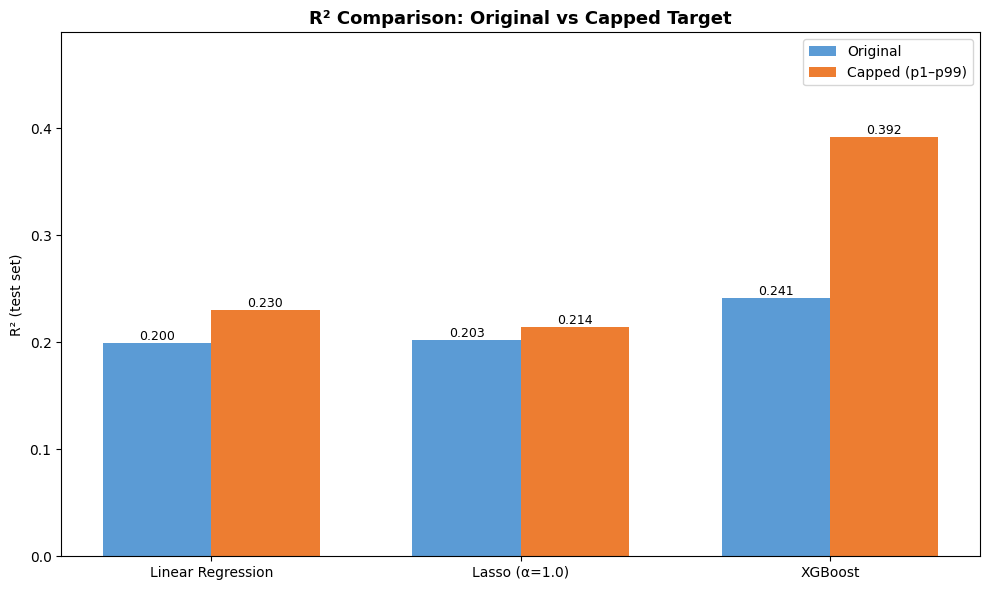

In [27]:
# Build combined results table
models = ['Linear Regression', 'Lasso (α=1.0)', 'XGBoost']
original_r2   = [r2_lr,   r2_lasso,   r2_xgb]
original_mae  = [mae_lr,  mae_lasso,  mae_xgb]
original_rmse = [rmse_lr, rmse_lasso, rmse_xgb]

capped_r2   = [results_cap[m]['R²']   for m in models]
capped_mae  = [results_cap[m]['MAE']  for m in models]
capped_rmse = [results_cap[m]['RMSE'] for m in models]

full_results = pd.DataFrame({
    'Model':   models * 2,
    'Dataset': ['Original'] * 3 + ['Capped (p1–p99)'] * 3,
    'R²':    original_r2   + capped_r2,
    'MAE':   original_mae  + capped_mae,
    'RMSE':  original_rmse + capped_rmse,
})

display(full_results.round(4))

# Delta table: gain from capping
delta = pd.DataFrame({
    'Model': models,
    'Δ R² (capped − original)': [c - o for c, o in zip(capped_r2, original_r2)],
})
print("\nR² gain from winsorisation:")
display(delta.round(4))

# Grouped bar chart — R² only (MAE/RMSE not comparable across scales)
fig, ax = plt.subplots(figsize=(10, 6))

x      = np.arange(len(models))
width  = 0.35
bars_o = ax.bar(x - width/2, original_r2, width, label='Original',        color='#5b9bd5')
bars_c = ax.bar(x + width/2, capped_r2,  width, label='Capped (p1–p99)', color='#ed7d31')

for bar in list(bars_o) + list(bars_c):
    ax.annotate(
        f'{bar.get_height():.3f}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center', va='bottom', fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('R² (test set)')
ax.set_title('R² Comparison: Original vs Capped Target', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, max(capped_r2) * 1.25)

plt.tight_layout()
plt.show()

## 15. Sensitivity Interpretation

### What the numbers say

Capping at the 1st and 99th percentile (bounds: −266.45 pp / +86.96 pp) affected exactly **32 rows on each side** — just 2% of the dataset. The effect on model performance was anything but symmetric across model types:

| Model | Original R² | Capped R² | Δ R² |
|---|---|---|---|
| Linear Regression | 0.1997 | 0.2302 | +0.03 |
| Lasso (α=1.0) | 0.2026 | 0.2140 | +0.01 |
| **XGBoost** | **0.2414** | **0.3918** | **+0.15** |

### The XGBoost finding

XGBoost gained 15 percentage points of R² from removing just 32 extreme observations. This is a **large jump** — it means the extreme negative-margin tasks were specifically suppressing XGBoost's ability to learn non-linear patterns. When those 32 tasks no longer dominate the loss function, XGBoost can explain **39% of margin variance** for the remaining 99% of tasks. The threshold and interaction effects it detected are real; they were simply being overwhelmed by the extreme outliers in the uncapped training run.

The widening gap between XGBoost and the linear models under capping is equally important:
- **Original**: XGBoost vs Linear gap = 0.04 R²
- **Capped**: XGBoost vs Linear gap = 0.16 R²

This confirms that the AI–margin threshold effects discovered in the EDA are genuinely non-linear and that XGBoost is capturing them — but only once the extreme-outlier noise is removed from the signal.

### The Lasso paradox

Lasso performed *worse* than Linear Regression on the capped target (R² 0.2140 vs 0.2302), despite both using linear models. This happens because the reduced noise in the capped target makes more features marginally informative — features that Lasso's aggressive α=1.0 penalty discards as noise. A lower α (e.g. 0.1 or tuned via `LassoCV`) would likely retain more features and improve performance on the capped dataset.

### Two populations, two problems

The results point to a structural split in Alkemy's task data:

1. **Typical tasks (98% of the dataset)**: XGBoost can explain ~39% of margin variance. This is operationally useful — the model can flag tasks likely to underperform before delivery based on observable features (AI intensity, complexity, team, quality inputs).

2. **Extreme tasks (2% of the dataset, margin < −266%)**: These are catastrophic cost-overrun events that no task-level ML model can reliably predict. They require a separate risk management approach — manual review triggers, contract safeguards, or client escalation protocols — rather than a predictive model.

### Which model to report?

Both results should be presented together, as done here. The **uncapped model is the honest baseline** — it operates on the full risk spectrum of Alkemy's tasks and its R² of 0.24 is the unbiased estimate of what task-level features can predict. The **capped model reveals the true ceiling** for typical-task prediction (R² ≈ 0.39) and demonstrates that the signal exists but is being drowned by a small number of extreme events.

Reporting only the capped R² would be misleading; reporting only the uncapped R² would undersell the model's practical utility for the 98% of tasks where extreme overruns are not occurring.

---
## Step 1 — LassoCV: Finding the Optimal Regularisation Strength

The fixed `alpha=1.0` used earlier was chosen as a reasonable default, but the sensitivity analysis revealed a problem: on the capped target Lasso underperformed plain Linear Regression (R² 0.2140 vs 0.2302). This means `alpha=1.0` is over-penalising — it discards features that carry real signal in the cleaner distribution.

`LassoCV` solves this by searching over a range of `alpha` values using 5-fold cross-validation and automatically selecting the one that minimises the CV mean squared error. We run it separately on the original and capped targets because the optimal regularisation strength differs between the two distributions.

The output shows: the chosen `alpha`, how many features survive the penalty at that alpha, and the test metrics compared to the fixed `alpha=1.0` baseline.

In [28]:
from sklearn.linear_model import LassoCV

# ── Original target ───────────────────────────────────────────────────────────
lassocv_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', LassoCV(cv=5, max_iter=10_000, random_state=42)),
])
lassocv_pipe.fit(X_train, y_train)
y_pred_lassocv = lassocv_pipe.predict(X_test)

alpha_orig   = lassocv_pipe.named_steps['model'].alpha_
coefs_orig   = lassocv_pipe.named_steps['model'].coef_
r2_lassocv   = r2_score(y_test, y_pred_lassocv)
mae_lassocv  = mean_absolute_error(y_test, y_pred_lassocv)
rmse_lassocv = np.sqrt(mean_squared_error(y_test, y_pred_lassocv))

print("=== LassoCV — Original target ===")
print(f"  Best alpha          : {alpha_orig:.4f}")
print(f"  Non-zero features   : {(coefs_orig != 0).sum()} / {len(coefs_orig)}")
print(f"  R²                  : {r2_lassocv:.4f}  (fixed alpha=1.0 was {r2_lasso:.4f})")
print(f"  MAE                 : {mae_lassocv:.4f}")
print(f"  RMSE                : {rmse_lassocv:.4f}")

# ── Capped target ─────────────────────────────────────────────────────────────
lassocv_cap_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', LassoCV(cv=5, max_iter=10_000, random_state=42)),
])
lassocv_cap_pipe.fit(X_train, y_train_cap)
y_pred_lassocv_cap = lassocv_cap_pipe.predict(X_test)

alpha_cap       = lassocv_cap_pipe.named_steps['model'].alpha_
coefs_cap       = lassocv_cap_pipe.named_steps['model'].coef_
r2_lassocv_cap  = r2_score(y_test_cap, y_pred_lassocv_cap)
mae_lassocv_cap = mean_absolute_error(y_test_cap, y_pred_lassocv_cap)

print("\n=== LassoCV — Capped target ===")
print(f"  Best alpha          : {alpha_cap:.4f}")
print(f"  Non-zero features   : {(coefs_cap != 0).sum()} / {len(coefs_cap)}")
print(f"  R²                  : {r2_lassocv_cap:.4f}  (fixed alpha=1.0 was {results_cap['Lasso (α=1.0)']['R²']:.4f})")
print(f"  MAE                 : {mae_lassocv_cap:.4f}")

=== LassoCV — Original target ===
  Best alpha          : 0.6109
  Non-zero features   : 26 / 45
  R²                  : 0.2064  (fixed alpha=1.0 was 0.2026)
  MAE                 : 31.6137
  RMSE                : 48.5053

=== LassoCV — Capped target ===
  Best alpha          : 0.4153
  Non-zero features   : 26 / 45
  R²                  : 0.2292  (fixed alpha=1.0 was 0.2140)
  MAE                 : 30.1918


## Step 2 — XGBoost with Huber Loss

Capping the target (Step 12–15) removed 32 extreme observations from the training loss. Huber loss is a more principled alternative: it trains on the **full, unmodified dataset** but uses a loss function that is quadratic for small errors (like MSE) and linear for large errors (like MAE). This means extreme outliers still contribute to training, but their squared-error penalty is replaced by a linear one — they no longer dominate the gradient updates.

XGBoost implements this via `objective='reg:pseudohubererror'`. We train on the original (uncapped) target and evaluate on the original test set, making this a direct, fair comparison against the standard MSE XGBoost (R² = 0.2414).

If Huber loss outperforms MSE on the original target, it confirms that the outliers were hurting training — and gives us a single model that handles the full distribution without any preprocessing choice.

In [29]:
xgb_huber_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', xgb.XGBRegressor(
        n_estimators     = 300,
        learning_rate    = 0.05,
        max_depth        = 4,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        objective        = 'reg:pseudohubererror',
        random_state     = 42,
        verbosity        = 0,
    )),
])

xgb_huber_pipe.fit(X_train, y_train)
y_pred_huber = xgb_huber_pipe.predict(X_test)

r2_huber   = r2_score(y_test, y_pred_huber)
mae_huber  = mean_absolute_error(y_test, y_pred_huber)
rmse_huber = np.sqrt(mean_squared_error(y_test, y_pred_huber))

print("=== XGBoost — Huber loss (original, uncapped target) ===")
print(f"  R²   : {r2_huber:.4f}")
print(f"  MAE  : {mae_huber:.4f}")
print(f"  RMSE : {rmse_huber:.4f}")
print(f"\nComparison (all trained and evaluated on original target):")

huber_summary = pd.DataFrame({
    'Model':  ['XGBoost MSE', 'XGBoost Huber'],
    'R²':     [r2_xgb,   r2_huber],
    'MAE':    [mae_xgb,  mae_huber],
    'RMSE':   [rmse_xgb, rmse_huber],
})
display(huber_summary.round(4))
print(f"\n  Δ R² (Huber − MSE) : {r2_huber - r2_xgb:+.4f}")

=== XGBoost — Huber loss (original, uncapped target) ===
  R²   : 0.3523
  MAE  : 24.6822
  RMSE : 43.8186

Comparison (all trained and evaluated on original target):


,Model,R²,MAE,RMSE
0,XGBoost MSE,0.2414,29.1423,47.4235
1,XGBoost Huber,0.3523,24.6822,43.8186



  Δ R² (Huber − MSE) : +0.1110


## Step 3 — XGBoost Hyperparameter Tuning

The XGBoost configuration used so far (`n_estimators=300`, `learning_rate=0.05`, `max_depth=4`) was a conservative default, not an optimised setting. `RandomizedSearchCV` samples 30 random combinations from a defined parameter grid, evaluates each with 5-fold cross-validation on the **capped target** (where the signal is clearest, R² = 0.39), and selects the combination that maximises CV R².

Parameters searched:
- `n_estimators`: number of trees (200–600)
- `learning_rate`: step size per tree (0.01–0.15)
- `max_depth`: maximum tree depth (3–6)
- `subsample` / `colsample_bytree`: row and column subsampling (0.6–1.0)
- `min_child_weight`: minimum sum of instance weight per leaf (1–7) — controls overfitting
- `reg_alpha` / `reg_lambda`: L1 and L2 regularisation on leaf weights

With `n_jobs=-1` the 5 CV folds run in parallel. The output shows the best parameter set, the CV R² achieved, and the test set metrics.

In [30]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'model__n_estimators':     [200, 300, 400, 500, 600],
    'model__learning_rate':    [0.01, 0.03, 0.05, 0.1, 0.15],
    'model__max_depth':        [3, 4, 5, 6],
    'model__subsample':        [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__min_child_weight': [1, 3, 5, 7],
    'model__reg_alpha':        [0, 0.1, 0.5, 1.0],
    'model__reg_lambda':       [0.5, 1.0, 2.0, 5.0],
}

base_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', xgb.XGBRegressor(random_state=42, verbosity=0)),
])

search = RandomizedSearchCV(
    base_pipe,
    param_distributions = param_dist,
    n_iter      = 30,
    cv          = 5,
    scoring     = 'r2',
    random_state= 42,
    n_jobs      = -1,
    refit       = True,
)

search.fit(X_train, y_train_cap)

print("=== Best parameters ===")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k:<35} {v}")

print(f"\n  Best CV R² (5-fold, capped train) : {search.best_score_:.4f}")

# Evaluate on test set
y_pred_tuned   = search.best_estimator_.predict(X_test)
r2_tuned       = r2_score(y_test_cap, y_pred_tuned)
mae_tuned      = mean_absolute_error(y_test_cap, y_pred_tuned)
rmse_tuned     = np.sqrt(mean_squared_error(y_test_cap, y_pred_tuned))

print(f"\n=== Tuned XGBoost — Capped test set ===")
print(f"  R²   : {r2_tuned:.4f}  (default params was {r2_xgb:.4f} original / {results_cap['XGBoost']['R²']:.4f} capped)")
print(f"  MAE  : {mae_tuned:.4f}")
print(f"  RMSE : {rmse_tuned:.4f}")
print(f"  Δ R² vs default capped XGBoost : {r2_tuned - results_cap['XGBoost']['R²']:+.4f}")

=== Best parameters ===
  model__colsample_bytree             1.0
  model__learning_rate                0.03
  model__max_depth                    4
  model__min_child_weight             7
  model__n_estimators                 300
  model__reg_alpha                    0.5
  model__reg_lambda                   5.0
  model__subsample                    0.8

  Best CV R² (5-fold, capped train) : 0.3149

=== Tuned XGBoost — Capped test set ===
  R²   : 0.3962  (default params was 0.2414 original / 0.3918 capped)
  MAE  : 26.1245
  RMSE : 39.7510
  Δ R² vs default capped XGBoost : +0.0044


## Step 4 — SHAP on the Tuned Capped Model: Global Feature Importance

The earlier SHAP analysis (Section 9) used the default XGBoost trained on the uncapped target (R² = 0.24). The tuned model trained on the capped target is significantly more predictive (R² ≈ 0.39+), so its SHAP values are more informative and less distorted by the extreme outliers.

We extract the fitted model from `search.best_estimator_`, transform the test set using the same preprocessor, and compute exact Shapley values with `TreeExplainer`. The beeswarm plot now reflects what the model learned about **typical Alkemy tasks** — the 98% of the distribution where the model's signal actually operates.

Key question: does `ai_usage_pct` rank higher in feature importance now that the outlier noise has been removed from training?

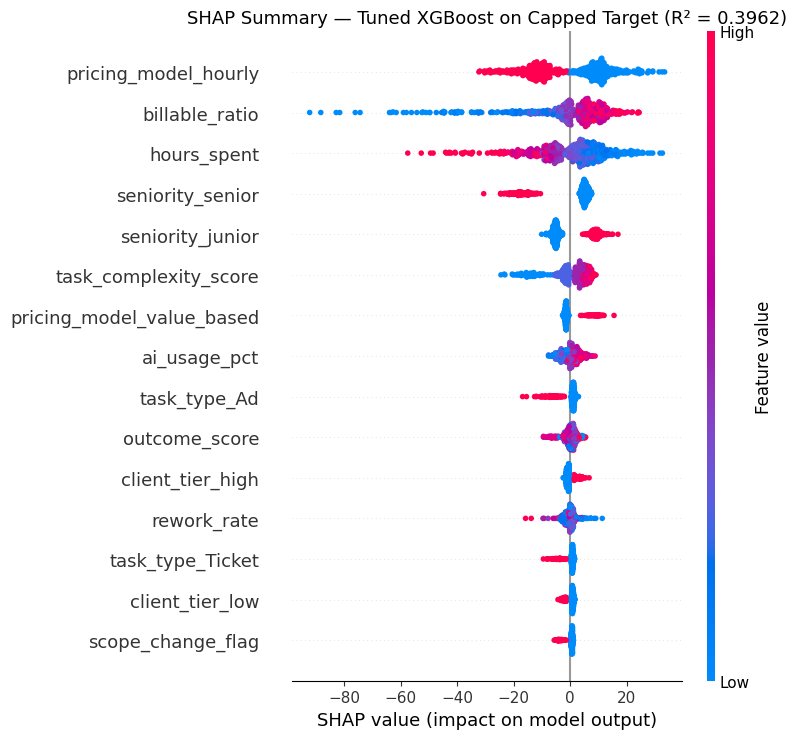

In [31]:
prep_tuned  = search.best_estimator_.named_steps['prep']
xgb_tuned   = search.best_estimator_.named_steps['model']

X_test_proc_tuned = prep_tuned.transform(X_test)
raw_names_tuned   = prep_tuned.get_feature_names_out()
feat_names_tuned  = [n.split('__', 1)[1] for n in raw_names_tuned]
X_test_df_tuned   = pd.DataFrame(X_test_proc_tuned, columns=feat_names_tuned)

explainer_tuned   = shap.TreeExplainer(xgb_tuned)
shap_vals_tuned   = explainer_tuned.shap_values(X_test_df_tuned)

shap.summary_plot(shap_vals_tuned, X_test_df_tuned, max_display=15, show=False)
plt.title(f'SHAP Summary — Tuned XGBoost on Capped Target (R² = {r2_tuned:.4f})', fontsize=13)
plt.tight_layout()
plt.show()

### SHAP Dependence Plot — AI Usage (Tuned Model)

The dependence plot on `ai_usage_pct` from the tuned capped model is the most reliable version of this analysis in the notebook: it reflects a model with R² ≈ 0.39 on the typical-task distribution, free from the influence of the 32 extreme outliers that suppressed the original SHAP analysis.

The shape of the SHAP curve here — whether linear, accelerating, or showing a threshold — is the model-level answer to the core research question.

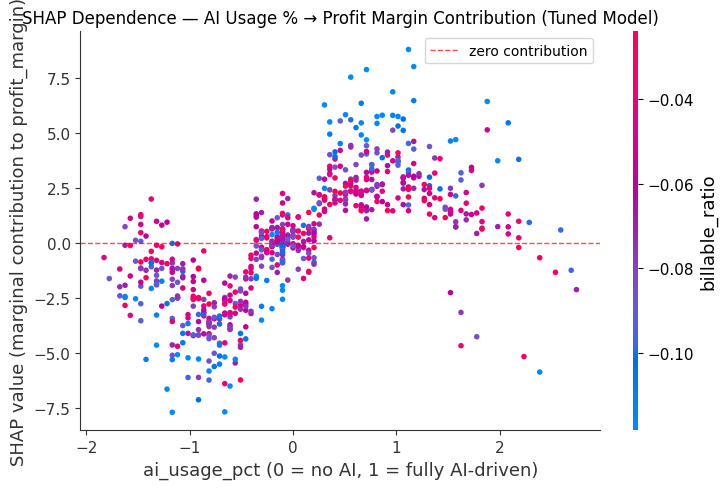

In [32]:
ai_idx_tuned = feat_names_tuned.index('ai_usage_pct')

shap.dependence_plot(
    ai_idx_tuned,
    shap_vals_tuned,
    X_test_df_tuned,
    feature_names = feat_names_tuned,
    show          = False,
)
ax = plt.gca()
ax.set_title('SHAP Dependence — AI Usage % → Profit Margin Contribution (Tuned Model)', fontsize=12)
ax.set_xlabel('ai_usage_pct (0 = no AI, 1 = fully AI-driven)')
ax.set_ylabel('SHAP value (marginal contribution to profit_margin)')
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='zero contribution')
ax.legend()
plt.tight_layout()
plt.show()

## Step 5 — Interaction Feature: AI Usage × Task Complexity

The research question asks whether AI increases margin *through speed or quality*. A natural follow-up is: **does AI help more on complex tasks?** If so, we would expect an interaction between `ai_usage_pct` and `task_complexity_score` — high AI usage on high-complexity tasks would generate disproportionately higher margin than either factor alone.

We create an explicit interaction term `ai_x_complexity = ai_usage_pct × task_complexity_score` and add it to the feature set. While XGBoost can in principle discover such interactions through its tree splits, an explicit term makes the relationship directly observable in SHAP and ensures the model has a direct linear signal to work with.

We re-train the best-parameter XGBoost from Step 3 on the augmented feature set (capped target) and check:
1. Does R² improve?
2. Does `ai_x_complexity` appear in the top SHAP features? If yes, the interaction is genuine.

=== XGBoost + Interaction Feature (capped target) ===
  R²   : 0.4076  (without interaction: 0.3962)
  MAE  : 25.7579
  RMSE : 39.3736
  Δ R² from interaction term : +0.0114

SHAP feature ranking (top 15):


,feature,mean_shap
0,pricing_model_hourly,12.1698
1,billable_ratio,10.3909
2,hours_spent,9.9146
3,seniority_senior,8.1775
4,seniority_junior,6.4632
5,ai_x_complexity,3.9461
6,task_complexity_score,3.0887
7,pricing_model_value_based,2.3664
8,task_type_Ad,2.0490
9,client_tier_high,1.5030



  Rank of ai_x_complexity : #6 out of 46 features


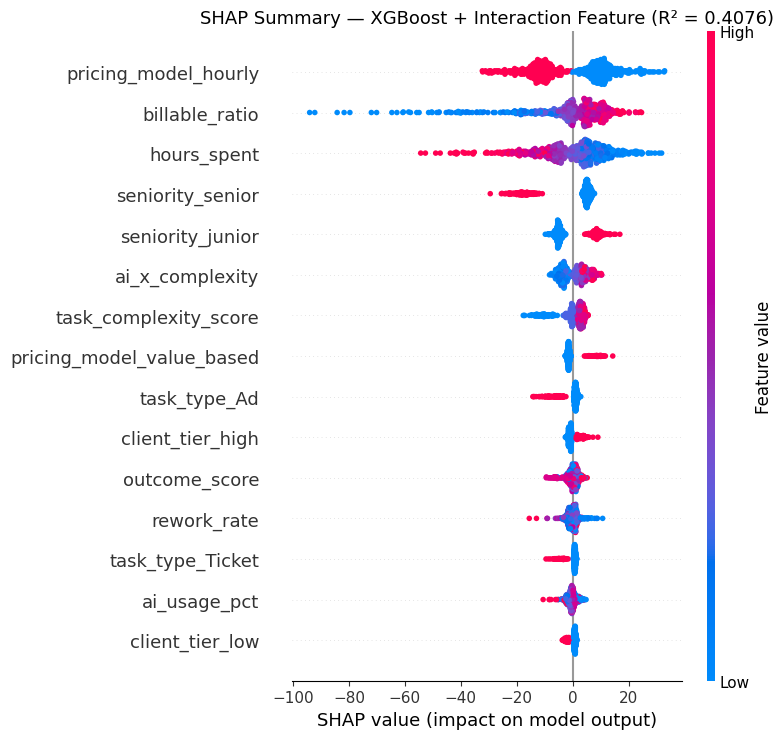

In [33]:
# Add interaction term to df (safe: both components are leakage-free features)
df['ai_x_complexity'] = df['ai_usage_pct'] * df['task_complexity_score']

FEATURES_AUG    = FEATURES + ['ai_x_complexity']
num_features_aug = num_features + ['ai_x_complexity']

preprocessor_aug = ColumnTransformer([
    ('num', numeric_pipeline, num_features_aug),
    ('cat', categorical_pipeline, cat_features),
])

# Align with the existing train/test split using the same indices
X_aug       = df.loc[X.index, FEATURES_AUG]
X_train_aug = X_aug.loc[X_train.index]
X_test_aug  = X_aug.loc[X_test.index]

# Extract best params found in Step 3 (strip pipeline prefix)
best_params_clean = {k.replace('model__', ''): v for k, v in search.best_params_.items()}

xgb_aug_pipe = Pipeline([
    ('prep',  preprocessor_aug),
    ('model', xgb.XGBRegressor(**best_params_clean, random_state=42, verbosity=0)),
])

xgb_aug_pipe.fit(X_train_aug, y_train_cap)
y_pred_aug = xgb_aug_pipe.predict(X_test_aug)

r2_aug   = r2_score(y_test_cap, y_pred_aug)
mae_aug  = mean_absolute_error(y_test_cap, y_pred_aug)
rmse_aug = np.sqrt(mean_squared_error(y_test_cap, y_pred_aug))

print("=== XGBoost + Interaction Feature (capped target) ===")
print(f"  R²   : {r2_aug:.4f}  (without interaction: {r2_tuned:.4f})")
print(f"  MAE  : {mae_aug:.4f}")
print(f"  RMSE : {rmse_aug:.4f}")
print(f"  Δ R² from interaction term : {r2_aug - r2_tuned:+.4f}")

# SHAP to check rank of the interaction feature
prep_aug      = xgb_aug_pipe.named_steps['prep']
xgb_aug_model = xgb_aug_pipe.named_steps['model']

X_test_proc_aug = prep_aug.transform(X_test_aug)
raw_names_aug   = prep_aug.get_feature_names_out()
feat_names_aug  = [n.split('__', 1)[1] for n in raw_names_aug]
X_test_df_aug   = pd.DataFrame(X_test_proc_aug, columns=feat_names_aug)

explainer_aug  = shap.TreeExplainer(xgb_aug_model)
shap_vals_aug  = explainer_aug.shap_values(X_test_df_aug)

# Rank features by mean |SHAP| and show top 15
shap_importance = pd.DataFrame({
    'feature':    feat_names_aug,
    'mean_shap':  np.abs(shap_vals_aug).mean(axis=0),
}).sort_values('mean_shap', ascending=False).reset_index(drop=True)

print("\nSHAP feature ranking (top 15):")
display(shap_importance.head(15).round(4))

interaction_rank = shap_importance[shap_importance['feature'] == 'ai_x_complexity'].index[0] + 1
print(f"\n  Rank of ai_x_complexity : #{interaction_rank} out of {len(feat_names_aug)} features")

shap.summary_plot(shap_vals_aug, X_test_df_aug, max_display=15, show=False)
plt.title(f'SHAP Summary — XGBoost + Interaction Feature (R² = {r2_aug:.4f})', fontsize=13)
plt.tight_layout()
plt.show()